# Miniproyecto 3: Clasificación de animales

## Entrega 3
Hasta ahora, hemos aprendido a representar nuestras imágenes utilizando descriptores de textura y color, así como a utilizar el clasificador de vecino más cercano para clasificarlas. En esta entrega, aprenderemos un nuevo método de representación basado en la forma. Además, veremos cómo enriquecer nuestros descriptores de histogramas para incorporar información espacial. Finalmente, combinaremos la información de color y forma para crear un nuevo tipo de descriptor multimodal. Todo esto nos ayudará a representar la imagen de una manera mucho más rica y obtener mejores resultados. Finalmente, utilizaremos un nuevo clasificador llamado Support Vector Machine (SVM) para capturar la complejidad de los descriptores de una manera más fiel.

In [2]:
# importar librerias
import os
import random
import numpy as np
from tqdm import tqdm
from glob import glob
from matplotlib import pyplot as plt

import cv2
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support

In [3]:
group = 13

In [4]:
def determine_classes(group: int) -> list:
    """Función que determina las clases a utilizar en el proyecto.

    Args:
        group (int): Número de grupo.

    Returns:
        list: Lista con los nombres de las clases a utilizar.
    """
    # Se fija la semilla para reproducibilidad
    random.seed(group)
    
    # Se obtienen las categorías y la cantidad de imágenes por categoría
    stats = [('Canis latrans', 1286), ('Castor canadensis', 854), ('Dasypus novemcinctus', 515), ('Didelphis virginiana', 713), 
             ('Lepus californicus', 515), ('Lynx rufus', 854), ('Megaptera novaeangliae', 515), ('Mephitis mephitis', 515), 
             ('Odocoileus hemionus', 1286), ('Odocoileus virginianus', 1795), ('Otospermophilus beecheyi', 854), 
             ('Otospermophilus variegatus', 515), ('Phoca vitulina', 713), ('Procyon lotor', 1286), ('Sciurus carolinensis', 1795), 
             ('Sciurus niger', 1795), ('Sylvilagus audubonii', 515), ('Sylvilagus floridanus', 854), ('Tamias striatus', 854), 
             ('Tamiasciurus hudsonicus', 713), ('Urocyon cinereoargenteus', 515), ('Ursus americanus', 713), ('Vulpes vulpes', 854)]
    
    # Se agrupan las categorías por cantidad de imágenes
    clusters = {}
    for category, num_images in stats:
        if num_images in clusters:
            clusters[num_images].append(category)
        else:
            clusters[num_images] = [category]
    
    # Se selecciona una categoría aleatoria de cada cluster
    categories = []
    for cluster_categories in clusters.values():
        categories += [random.choice(cluster_categories)]
    return categories

assert group is not None, "Por favor, asigna un número de grupo a la variable 'group'."
assert group > 0, "El número de grupo debe ser mayor que 0."
assert group <= 28, "El número de grupo debe ser menor o igual que 28."

categories = determine_classes(group)
print(f"Las classes que usarán en este Mini-proyecto serán:\n{", ".join(categories)}.")

Las classes que usarán en este Mini-proyecto serán:
Odocoileus hemionus, Otospermophilus beecheyi, Sylvilagus audubonii, Phoca vitulina, Sciurus niger.


In [5]:
dict_labels = {} # Cambiar por un diccionario con las etiquetas de las clases 

# YOUR CODE HERE
clases= ["Odocoileus hemionus","Otospermophilus beecheyi","Phoca vitulina","Sciurus niger", "Sylvilagus audubonii"]
dict_labels={"Odocoileus hemionus":0, "Otospermophilus beecheyi":1,"Phoca vitulina":2,"Sciurus niger":3, "Sylvilagus audubonii":4}


def get_data(subset: str) -> tuple[list, list]:
    """Función que obtiene las rutas de las imágenes y sus etiquetas.

    Args:
        subset (str): Nombre del subconjunto de datos

    Returns:
        tuple[list, list]: Rutas de las imágenes y sus etiquetas.
    """
    
    
    paths=[] # Cambiar por una lista con las rutas de las imágenes 
    labels=[] # Cambiar por una lista con las etiquetas de las imágenes
    
    # Construimos la ruta base al subconjunto (train, valid o test)
    
    base_path=f"dataset/{subset}"
    
    # Recorremos cada una de las clases que nos asignaron
    for nombre in clases:
        # Construimos la ruta de la carpeta de esa clase
        class_path = os.path.join(base_path, nombre)
        # Usamos glob para obtener todas las imágenes dentro de esa carpeta
        image_paths = glob(os.path.join(class_path, "*"))
        # Ahora recorremos cada imagen encontrada
        for img_path in image_paths:
            # Guardamos la ruta de la imagen
            paths.append(img_path)
            # Guardamos la etiqueta correspondiente usando el diccionario
            # Convertimos el nombre de la clase a su ID numérico
            labels.append(dict_labels[nombre])
    # Al final devolvemos ambas listas
    return paths, labels
train_paths, train_labels = get_data("train")
valid_paths, valid_labels = get_data("valid")
test_paths, test_labels = get_data("test")

In [6]:
assert len(train_paths) > 0, "No se ha cargado ningún dato de entrenamiento"
assert len(train_paths) == 5163, "El número de datos de entrenamiento no es correcto"
assert len(valid_paths) > 0, "No se ha cargado ningún dato de validación"
assert len(valid_paths) == 1723, "El número de datos de validación no es correcto"
assert len(test_paths) > 0, "No se ha cargado ningún dato de test"
assert len(test_paths) == 1724, "El número de datos de test no es correcto"

assert type(train_paths[0]) == str, "Los datos de entrenamiento no tienen la forma correcta"
assert type(valid_paths[0]) == str, "Los datos de validación no tienen la forma correcta"
assert type(test_paths[0]) == str, "Los datos de test no tienen la forma correcta"

assert type(train_labels[0]) == int, "Las etiquetas de entrenamiento no tienen la forma correcta"
assert type(valid_labels[0]) == int, "Las etiquetas de validación no tienen la forma correcta"
assert type(test_labels[0]) == int, "Las etiquetas de test no tienen la forma correcta"

assert len(dict_labels) == len(categories), "El diccionario de labels no tiene la longitud correcta"

categories_sorted = sorted(categories)
assert list(dict_labels.keys()) == categories_sorted, "Las llaves del diccionario de labels no son correctas"
assert list(dict_labels.values()) == list(range(len(categories))), "Los valores del diccionario de labels no son correctos"

assert min([dict_labels[train_paths[i].split(os.sep)[-2]] == train_labels[i] for i in range(len(train_paths))]), "Las etiquetas de entrenamiento no coinciden"
assert min([dict_labels[valid_paths[i].split(os.sep)[-2]] == valid_labels[i] for i in range(len(valid_paths))]), "Las etiquetas de validación no coinciden"
assert min([dict_labels[test_paths[i].split(os.sep)[-2]] == test_labels[i] for i in range(len(test_paths))]), "Las etiquetas de test no coinciden"

In [7]:
def processing(Im: np.ndarray, img_size: tuple[int] | None = None, color_space: str | None = None) -> np.ndarray:
    """Función que preprocesa una lista de imágenes.

    Args:
        Im_list (list[np.ndarray]): Lista con las imágenes a preprocesar.
        img_size (tuple[int] | None): Tamaño de la imagen.
        color_space (str | None): Espacio de color a utilizar. Puede ser "rgb", "gray", "hsv" o "lab".

    Returns:
        list[np.ndarray]: Lista con las imágenes preprocesadas.
    """
    
    Im_processed = Im.copy()
    
    if img_size is not None:
        Im_processed = cv2.resize(Im_processed, img_size)
        
    if color_space is not None:
        color_space = color_space.lower()
        if color_space == "rgb":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2RGB)
        elif color_space == "gray":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2GRAY)
        elif color_space == "hsv":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2HSV)
        elif color_space == "lab":
            Im_processed = cv2.cvtColor(Im_processed, cv2.COLOR_BGR2LAB)
    
    return Im_processed

In [8]:
Im_list = [cv2.imread(path) for path in train_paths[:5]]
img_size = (224, 224)
color_space = "rgb"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]

assert len(Im_proc) == len(Im_list), "El número de imágenes preprocesadas no es correcto"
assert type(Im_proc) == list, "Las imágenes preprocesadas no están en una lista"
assert type(Im_proc[0]) == np.ndarray, "Las imágenes preprocesadas no son arreglos de numpy"
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2RGB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "gray"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2GRAY), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "hsv"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2HSV), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "lab"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2LAB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

Im_proc = [processing(Im, (256, 256)) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (256, 256, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.resize(Im_list[0], (256, 256)), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

Im_proc = [processing(Im, None, "lab") for Im in Im_list]
assert np.array_equal(cv2.cvtColor(Im_list[0], cv2.COLOR_BGR2LAB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

### Parte 1: Histogramas
Recordemos que una de las formas más comunes de representar una imagen es utilizando histogramas de color, ya sea de manera concatenada o conjunta. Sin embargo, un problema que surge al usar histogramas es que se pierde la información espacial de la imagen.

Para recuperar esta información espacial, utilizaremos el concepto de una pirámide espacial. Esto implica dividir la imagen en varias secciones, y para cada sección calcularemos su propio histograma de color. Luego, concatenaremos todos los histogramas obtenidos para generar un descriptor de mayor dimensionalidad que preserve la consistencia espacial de la imagen.

#### Parte 1.1: Color
Copia la función de la entrega 2 llamada `color_hist`, que debe retornar el histograma conjunto o concatenado de color de una imagen de entrada, dada una cantidad de bins específica. Asegúrate de que el histograma esté normalizado antes de retornarlo.

In [9]:
def color_hist(Im: np.ndarray, type_h: str, bins: int) -> np.ndarray:
    """Función que calcula el histograma de color conjunto o concatenado de una imagen

    Args:
        Im (numpy.ndarray): Imagen a la que calcular el histograma
        type_h (str): Tipo de histograma a calcular, puede ser "concat" o "joint"
        bins (int): Cantidad de bins que usar en el histograma. En el caso de concat el número de bins finale será 3*bins
        En el caso de Joint será bins^3
        
    Returns:
        numpy.ndarray: Histograma de color normalizado
    """
    h = "" # Histograma de color normalizado
    
    if type_h.lower() == "concat":
        h = []
        for c in range(Im.shape[2]):
            hist, _ = np.histogram(Im[:, :, c].flatten(), bins=bins)
            h.append(hist)
        h = np.concatenate(h).astype(float)

    elif type_h.lower() == "joint":
        h, _ = np.histogramdd(
            Im.reshape(-1, 3).astype(float),
            bins=bins
        )
        h = h.flatten()

    h = h / h.sum()
    return h

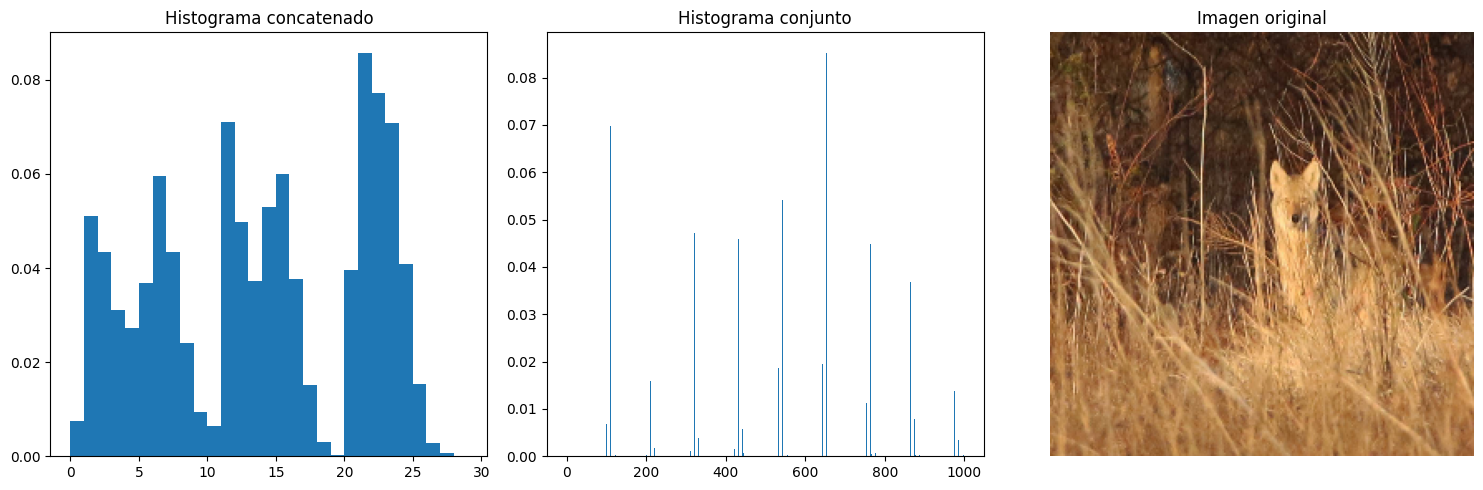

In [10]:
img=processing(cv2.imread(os.path.join(".", "dataset", "train", "Canis latrans", "f494fab00ebb2d87c8d3bf5215560d54.jpg")),  (256, 256), 'rgb')
concat_h=color_hist(img,'concat',10)
joint_h=color_hist(img,'joint',10)


fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].hist(list(range(len(concat_h))), list(range(len(concat_h - 1))), weights = concat_h)
ax[0].set_title('Histograma concatenado')
ax[1].hist(list(range(len(joint_h))), list(range(len(joint_h - 1))), weights = joint_h)
ax[1].set_title('Histograma conjunto')
ax[2].imshow(img)
ax[2].axis('off')
ax[2].set_title('Imagen original')

plt.tight_layout()

assert np.isclose(np.sum(concat_h),1,0.1), 'Su histograma concatenado no esta normalizado'
assert np.isclose(np.sum(joint_h),1,0.1), 'Su histograma conjunto no esta normalizado'
assert len(concat_h.shape)==1 and len(joint_h.shape)==1, 'Su histograma debe tener una unica dimension'
assert np.isclose(len(concat_h)/3,len(joint_h)**(1/3),0.01),' Sus histogramas no tienen la cantidad de bins que deberían'
assert np.isclose(np.std(concat_h),0.025,0.05), 'Su histograma de color concatenado es erroneo'
assert np.isclose(np.std(joint_h),0.0063,0.05), 'Su histograma de color conjunto es erroneo'

#### Parte 1.2: Piramide

Ahora que has copiado la función `color_hist` y tenemos una forma de obtener los histogramas de color conjunto o concatenado de una imagen, vamos a generar el descriptor final utilizando una pirámide espacial. Recordemos que la pirámide espacial es un método que nos permite preservar la información espacial de la imagen. Primero, obtenemos un histograma de toda la imagen, y luego dividimos la imagen en parches en los que calculamos un histograma para cada uno.

Un resumen de este método se muestra en la siguiente imagen:

![imagen](Piramide_espacial.png)

En este caso utilizaremos 3 niveles de la piramide. La función tendrá 4 parámetros: La imagen original, el tamaño de las ventanas en cada uno de los niveles, el tipo de histograma y el número de bins del histograma. El formato de la variable `size` que se asociará al tamaño de las ventanas o cuadrantes en cada uno de los niveles de la piramide el siguiente: [(256, 256), (128, 128), (64, 64)], para una imagen de tamaño $256\times256$ el primer nivel es la imagen completa, el segundo nivel dividiría la imagen en 4 y el tercer nivel dividiría la imagen en 8. 

Instrucciones:
1. Primero para cada nivel extrae el tamaño de la ventana o cuadrante de ese nivel.

2. Para cada parche de la imagen dentro de cada nivel, calcula el histograma y concaténalo con los histogramas de los otros parches para generar el descriptor final.

3. El descriptor final no estará normalizado, ya que será la concatenación de varios histogramas normalizados.

**Nota:** El orden para recorrer los parches será primero de izquierda a derecha y arriba a abajo. Comenzando en la esquina superior izquierda. Además, tengan en cuenta que el tamaño de los parches deben ser valores dado que el tamaño de la imagen sea divisible por ellos.

In [ ]:
def Color_pyramid(Im: np.ndarray, patch_sizes: list[tuple[int]], type_h: str, bins:int) -> np.ndarray:
    """Función que calcula el histograma de color de una imagen por parches

    Args:
        Im (numpy.ndarray): Imagen de entrada
        patch_sizes (list[tuple[int]]): Tupla tamaño de los parches sobre el que calcular cada histograma
        type_h (str): Puede ser "concat" o "joint"
        bins (int): Cantidad de bins que usar en el histograma

    Returns:
        numpy.ndarray: Histograma de color normalizado
    """
    # YOUR CODE HERE
    raise NotImplementedError()
    return final_histogram

In [ ]:
img=processing(cv2.imread(os.path.join(".", "dataset", "train", "Canis latrans", "f494fab00ebb2d87c8d3bf5215560d54.jpg")),  (256, 256), 'rgb')
h_pyramid_cat=Color_pyramid(img,[(256, 256), (128, 128), (64, 64)],'concat',10)
h_pyramid_joint=Color_pyramid(img,[(256, 256), (128, 128), (64, 64)],'joint',5)

fig,ax=plt.subplots(2,2,figsize=(10,10))
ax[0,0].imshow(img)
ax[0,0].axis('off')
ax[0,0].set_title('Imagen')
ax[0,1].hist(list(range(len(h_pyramid_cat))), list(range(len(h_pyramid_cat - 1))), weights = h_pyramid_cat)
ax[0,1].set_title('Histograma de piramide')

assert len(h_pyramid_cat)==30*(1+4+16), 'La longitud del descriptor final debe ser igual a la longitud del histograma concatenado multiplicado por la cantidad de cuadrantes dentro de la imagen'
assert np.isclose(np.sum(h_pyramid_cat),(1+4+16),0.01), 'En total se tienen 64 histogramas normalizados juntos, la suma de todo debe ser 64'
assert len(h_pyramid_joint)==5**3*(1+4+16), 'La longitud del descriptor final debe ser igual a la longitud del histograma conjunto multiplicado por la cantidad de cuadrantes dentro de la imagen'
assert np.isclose(np.sum(h_pyramid_joint),(1+4+16),0.01), 'En total se tienen 64 histogramas normalizados juntos, la suma de todo debe ser 64'
a=color_hist(img[64:64+64,64:64+64,:],'concat',10)
K=10
b=h_pyramid_cat[K*30:K*30+30]

ax[1,0].imshow(img[64:64+64,64:64+64,:])
ax[1,0].axis('off')
ax[1,0].set_title('Recorte')
ax[1,1].hist(list(range(len(h_pyramid_cat[K*30:K*30+30]))), list(range(len(h_pyramid_cat[K*30:K*30+30] - 1))), weights = h_pyramid_cat[K*30:K*30+30])
ax[1,1].set_title('Histograma de recorte')

assert np.array_equal(a,b), 'El histograma concatenado de el cuadrante 17 de la imagen debe ser igual la parte 17 del histograma en piramide'

#### Parte 1.3: Histograma de gradientes orientados
La representación basada en color es útil cuando existe una consistencia en la diferencia de colores entre clases. Por ejemplo, si quisiéramos clasificar vacas y caballos, este enfoque podría ser eficaz. Sin embargo, si intentamos clasificar vacas y cebras, el descriptor de color sería menos útil. Hasta ahora hemos experimentado con descriptores de color y textura, y ahora aprenderemos a usar una representación basada en forma.

El Histograma de Gradientes Orientados (HOG) es una técnica para representar la forma de un objeto en una imagen utilizando el gradiente y su orientación. Este método calcula un histograma de orientaciones en ventanas de un tamaño específico a lo largo de toda la imagen, y luego concatena estos histogramas.

**Instrucciones:**
1. Utiliza la función `hog` de la librería `skimage.feature` para obtener el histograma de gradientes orientados de una imagen.

2. Aplica esta función a una imagen de un gato y visualiza el histograma de gradientes orientados.

**Nota:** La función `hog` no solo retorna el histograma de gradientes orientados, sino que también puede generar el mapa de gradientes orientados usando el parámetro `visualize`.

In [ ]:
hist_hog='' #Histograma de gradientes de la imagen
hog_map='' #Imagen de mapa de histogramas de gradientes
# YOUR CODE HERE
raise NotImplementedError()

Es importante tener en cuenta que el algoritmo de HOG ya crea un descriptor que preserva la información espacial. Esto se debe a que el histograma de gradientes se calcula en celdas individuales a lo largo de la imagen, y luego se concatenan todos estos histogramas para formar el descriptor final.

### Parte 2: Entrenamiento
Hasta ahora, hemos aprendido a representar nuestras imágenes como vectores basados en diversas características visuales. Anteriormente, exploramos cómo clasificar estos vectores utilizando un algoritmo de vecino más cercano. En esta ocasión, aprenderemos a obtener una lista de descriptores de nuestras imágenes de entrenamiento para luego experimentar con un clasificador diferente: Support Vector Machines (SVM).

#### Parte 2.1: Descriptores
Usando las funciones desarrolladas anteriormente, obtén una lista de descriptores y una lista de etiquetas para cada imagen. Debes obtener el descriptor concatenado en pirámide y el descriptor HOG, según los parámetros que tú determines.

**Consejo:** Recuerden utilizar la función processing para cambiar el tamaño de las imágenes a $256\times256$ y cambiar el espacio de color. Puede utilizar otro tamaño si considera necesario pero debe ser consistente a lo largo de esta y la siguiente entrega.

In [ ]:
train_images_num='' #cantidad de imagens de entrenamiento
train_concat_color_pyramid_desc=[] #Descriptor de imagenes con histogramas concatenados de color en piramide
train_hog_desc=[] #Descriptor de imagenes con histogramas de gradientes orientados

valid_concat_color_pyramid_desc=[] #Descriptor de imagenes con histogramas concatenados de color en piramide
valid_hog_desc=[] #Descriptor de imagenes con histogramas de gradientes orientados

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert len(train_labels) == train_images_num, 'La cantidad de etiquetas que tiene debe ser igual a la cantidad de imagenes que usted especificó'
assert len(train_concat_color_pyramid_desc[0]) > 1, 'El descriptor debe tener más de una dimensión'
assert len(train_hog_desc[0]) > 1, 'El descriptor debe tener más de una dimensión'
assert len(train_concat_color_pyramid_desc[0]) <= 7056, 'Su descriptor unimodal de color tiene demasiadas dimensiones'
assert len(train_hog_desc[0]) <= 7056, 'Su descriptor unimodal de forma tiene demasiadas dimensiones'
assert len(train_concat_color_pyramid_desc) == len(train_hog_desc), 'Usted debe tener la misma cantidad de descriptores en todas las listas'
assert len(np.unique(train_labels)) == 5, 'Solo deben haber 5 etiquetas'
assert len(np.unique(valid_labels)) == 5, 'Solo deben haber 5 etiquetas'

assert len(valid_labels) == 1723, 'Usted debe sacar el descriptor de todas las imagenes de validación'
assert len(valid_hog_desc[0]) == len(train_hog_desc[0]), 'El descriptor del histograma concatenado en train y valid debe ser igual'

print(f"Las dimensiones de su descriptor de color son {np.array(train_concat_color_pyramid_desc).shape[1]}")
print(f"Las dimensiones de su descriptor de forma son {np.array(train_hog_desc).shape[1]}")

#### Parte 2.2: Entrenamiento
Ahora entrenaremos algunos modelos SVM para clasificar nuestros datos. Una parte fundamental del entrenamiento son los hiperparámetros, que influyen directamente en el rendimiento del modelo durante la etapa de optimización.

En el caso de los SVM, uno de los hiperparámetros clave es el valor de C, que controla el peso asignado a la mala clasificación de los datos. Un valor de C afecta el margen del hiperplano, influyendo en la capacidad del modelo para generalizar.

Otro hiperparámetro importante es el Kernel, que es la medida de similitud utilizada por el modelo SVM. Los kernels nos permiten manejar datos que no son linealmente separables. Algunos ejemplos comunes de kernels son el Kernel Lineal y el Kernel RBF (Radial Basis Function).

En Machine Learning y Visión por Computador, la fase de experimentación es crucial. Los experimentos deben ser consistentes y exhaustivos para que los resultados sean comparables entre sí.

**Instrucciones:**
1. Usa la función SVC de sklearn.svm para definir los modelos SVM.

2. Entrena varios modelos de SVM variando los hiperparámetros, en este caso:

    - Experimenta con 2 diferentes kernels.
    - Experimenta con 2 diferentes valores de C.

El objetivo es observar cómo el rendimiento del clasificador varía al modificar estos hiperparámetros y descriptores.

In [ ]:
svm_kernel1_C1_concatcolorPyram='' #SVM con un kernel 1 especificado con C1 especificado y entrenado con concat color en piramide
svm_kernel2_C1_concatcolorPyram='' #SVM con un kernel 2 especificado con C1 especificado y entrenado con concat color en piramide
svm_kernel1_C2_concatcolorPyram='' #SVM con un kernel 1 especificado con C2 especificado y entrenado con concat color en piramide
svm_kernel2_C2_concatcolorPyram='' #SVM con un kernel 2 especificado con C2 especificado y entrenado con concat color en piramide

svm_kernel1_C1_hog='' #SVM con un kernel 1 especificado con C1 especificado y entrenado con hog
svm_kernel2_C1_hog='' #SVM con un kernel 2 especificado con C1 especificado y entrenado con hog
svm_kernel1_C2_hog='' #SVM con un kernel 1 especificado con C2 especificado y entrenado con hog
svm_kernel2_C2_hog='' #SVM con un kernel 2 especificado con C2 especificado y entrenado con hog

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert not svm_kernel1_C1_concatcolorPyram.fit_status_, 'Su modelo no esta entrenado'
assert not svm_kernel2_C1_concatcolorPyram.fit_status_, 'Su modelo no esta entrenado'
assert not svm_kernel1_C2_concatcolorPyram.fit_status_, 'Su modelo no esta entrenado'
assert not svm_kernel2_C2_concatcolorPyram.fit_status_, 'Su modelo no esta entrenado'

assert not svm_kernel1_C1_hog.fit_status_, 'Su modelo no esta entrenado'
assert not svm_kernel2_C1_hog.fit_status_, 'Su modelo no esta entrenado'
assert not svm_kernel1_C2_hog.fit_status_, 'Su modelo no esta entrenado'
assert not svm_kernel2_C2_hog.fit_status_, 'Su modelo no esta entrenado'

#Caracteristicas
assert len(train_concat_color_pyramid_desc[0]) == svm_kernel1_C1_concatcolorPyram.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'
assert len(train_concat_color_pyramid_desc[0]) == svm_kernel2_C1_concatcolorPyram.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'
assert len(train_concat_color_pyramid_desc[0]) == svm_kernel1_C2_concatcolorPyram.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'
assert len(train_concat_color_pyramid_desc[0]) == svm_kernel2_C2_concatcolorPyram.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'

assert len(train_hog_desc[0]) == svm_kernel1_C1_hog.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'
assert len(train_hog_desc[0]) == svm_kernel2_C1_hog.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'
assert len(train_hog_desc[0]) == svm_kernel1_C2_hog.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'
assert len(train_hog_desc[0]) == svm_kernel2_C2_hog.n_features_in_, 'Su modelo no esta entrenado con el descriptor correcto'

Una vez que tenemos nuestros modelos entrenados, vamos a obtener las predicciones y las métricas de rendimiento.

**Instrucciones:**
1. Utiliza los modelos entrenados junto con los descriptores de validación para obtener las predicciones de cada uno.
2. Calcule la métrica F1-score para cada modelo.

In [ ]:
predict_svm_kernel1_C1_concatcolorPyram='' #Predict de modelo con con un kernel 1 especificado con C1 especificado y entrenado con concat color en piramide
predict_svm_kernel2_C1_concatcolorPyram='' #Predict de modelo con con un kernel 2 especificado con C1 especificado y entrenado con concat color en piramide
predict_svm_kernel1_C2_concatcolorPyram='' #Predict de modelo con con un kernel 1 especificado con C2 especificado y entrenado con concat color en piramide
predict_svm_kernel2_C2_concatcolorPyram='' #Predict de modelo con con un kernel 2 especificado con C2 especificado y entrenado con concat color en piramide

predict_svm_kernel1_C1_hog='' #Predict de modelo con con un kernel 1 especificado con C1 especificado y entrenado con hog
predict_svm_kernel2_C1_hog='' #Predict de modelo con con un kernel 2 especificado con C1 especificado y entrenado con hog
predict_svm_kernel1_C2_hog='' #Predict de modelo con con un kernel 1 especificado con C2 especificado y entrenado con hog
predict_svm_kernel2_C2_hog='' #Predict de modelo con con un kernel 2 especificado con C2 especificado y entrenado con hog

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert len(predict_svm_kernel1_C1_concatcolorPyram)==1723, 'Deben tener 1723 predicciones en validación'
assert len(predict_svm_kernel1_C1_hog)==1723, 'Deben tener 1723 predicciones en validación'
assert len(np.unique(predict_svm_kernel1_C1_hog))==5, 'Deberían haber 5 etiquetas en sus predicciones'
assert np.mean(np.std([predict_svm_kernel1_C1_hog,predict_svm_kernel2_C1_hog,predict_svm_kernel1_C2_hog,predict_svm_kernel2_C2_hog],axis=1))>0.1, 'Sus predicciones son iguales'

In [ ]:
f_kernel1_C1_concatcolorPyram='' #F medida de modelo kernel1 C1 y concatcolorPyram 
f_kernel2_C1_concatcolorPyram='' #F medida de modelo kernel2 C1 y concatcolorPyram 
f_kernel1_C2_concatcolorPyram='' #F medida de modelo kernel1 C2 y concatcolorPyram 
f_kernel2_C2_concatcolorPyram='' #F medida de modelo kernel2 C2 y concatcolorPyram 

f_kernel1_C1_hog='' #F medida de modelo kernel1 C1 y hog 
f_kernel2_C1_hog='' #F medida de modelo kernel2 C1 y hog 
f_kernel1_C2_hog='' #F medida de modelo kernel1 C2 y hog 
f_kernel2_C2_hog='' #F medida de modelo kernel2 C2 y hog 

# YOUR CODE HERE
raise NotImplementedError()

La métrica importante en este caso es la F1-score (F medida), en particular, la F1 media entre todas las clases. El objetivo de realizar una experimentación exhaustiva es observar la interacción de los parámetros y la mejor forma de representar nuestras imágenes.

Es posible que uno de los descriptores produzca, en general, mejores métricas de clasificación en todos los experimentos. Esto te ayudará a guiar tus conclusiones sobre cuál es la mejor forma de describir una clase, ya sea mediante su forma o su color.

Por otro lado, es crucial analizar la interacción entre los hiperparámetros, ya que el uso de un kernel específico podría proporcionar mejores resultados con un valor de C mayor o menor, dependiendo de la distribución de los datos de entrenamiento. Esta experimentación con hiperparámetros nos permitirá acercarnos al mejor modelo posible.

El objetivo de esta parte del miniproyecto es mostrarte la importancia de una experimentación exhaustiva, cómo diseñar los experimentos y cómo interpretar los resultados finales. Ahora es tu trabajo continuar experimentando para obtener los mejores resultados a partir de los modelos que hemos entrenado.

Finalmente, guarda tu mejor modelo en las variables proporcionadas en la siguiente celda.

In [ ]:
final_model='' #Modelo final entrenado
final_train_descriptor='' #Lista de descriptores en su modelo final en entrenamiento
final_valid_descriptor='' #Lista de descriptores en su modelo final en validación
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
final_predict=final_model.predict(final_valid_descriptor)

In [ ]:

_,_,f_final,_=precision_recall_fscore_support(valid_labels,final_predict,average='macro')

assert len(final_valid_descriptor[0])==final_model.n_features_in_, 'Su modelo no fue entrenado con el mismo descriptor con el que se evalua'
assert f_final>0.55, 'Necesita refinar su modelo'

### Parte 3: Descriptor multimodal
Usar una única forma de describir una imagen puede ser limitado. Por ejemplo, un caballo se puede diferenciar de un elefante por su color, pero no tanto por su forma, mientras que un perro se puede diferenciar de un gato por su forma, pero no necesariamente por su color. Por lo tanto, es importante combinar diferentes descriptores para mejorar la capacidad de nuestros modelos.

#### Parte 3.1: Concatenación de descriptores de color y forma
Una de las formas más simples de combinar varios descriptores es crear un descriptor de mayor dimensionalidad que integre diferentes fuentes de información concatenando los vectores. En las siguientes celdas implementaremos de manera sencilla esta idea. Solamente necesitan utilizar la función `np.concatenate` de numpy y los descriptores de cada modalidad que utilizamos anteriormente.

In [ ]:
train_multimodal_desc = "" #Descriptor multimodal de entrenamiento
val_multimodal_desc = "" #Descriptor multimodal de validación
svm_multimodal_desc = "" #Modelo SVM entrenado con descriptor multimodal
predict_svm_multimodal_desc = "" #Predicción de modelo SVM entrenado con descriptor multimodal
f_multimodal_desc = "" #F medida de modelo SVM entrenado con descriptor multimodal

# YOUR CODE HERE
raise NotImplementedError()

print(f"El valor de la F medida de su modelo multimodal es {f_multimodal_desc}")

In [ ]:
assert len(train_multimodal_desc[0])==len(train_concat_color_pyramid_desc[0])+len(train_hog_desc[0]), 'Su descriptor multimodal no tiene la cantidad de dimensiones correctas'
assert svm_multimodal_desc.fit_status_==False, 'Su modelo no esta entrenado'
assert len(predict_svm_multimodal_desc)==1723, 'Deben tener 1723 predicciones en validación'
assert f_multimodal_desc>0.55, 'Necesita refinar su modelo multimodal'

## Entregables
Los entregables para esta entrega son los siguientes:

- Jupyter notebook (.ipynb): El notebook debe estar completamente resuelto. Recuerden que la evaluación depende del funcionamiento correcto del código.

- Secciones requeridas del artículo (.pdf): El artículo debe tener una extensión máxima de 6 páginas (4 páginas nuevas agregadas a las 2 de entregas pasadas). El formato para el artículo se puede encontrar en el siguiente [enlace](https://github.com/cvpr-org/author-kit). Si tienen dudas sobre cómo utilizar el formato, pueden consultar al Asistente Graduado.

- Archivo de texto (.txt): Este archivo contendrá las secciones de código del Jupyter notebook. Para más información sobre cómo convertir las secciones de código del notebook a un archivo de texto, revisen el video en el siguiente [enlace](https://uniandes-edu-co.zoom.us/rec/share/QOxUUIw7Uz9DsnKPyftOXZgM4bx5d7KHMYK-dqvGnkyJ2GfqvT7NU3lhQc0NtNSU.jveWB2H34S4uLIoB).

## Artículo
El artículo debe construirse de forma progresiva, por lo que en esta entrega agregaremos lo que se realizó.

### Descriptores
En esta sección, deberán explicar los descriptores que han utilizado. Describan los descriptores unimodales usados en las entregas (color, forma, textura), los parámetros que se pueden variar y el propósito de esos parámetros.

Para orientar la descripción, pueden basarse en las siguientes preguntas:

>- ¿En qué consistía su descriptor?
>- ¿Qué pretendía mostrar?
>- ¿Qué características de la imagen usa?
>- ¿Por qué este descriptor sería de utilidad?

### Resultados: Descriptores
Antes de seleccionar el baseline, agreguen los resultados de clasificación obtenidos con los descriptores unimodales de color, textura y forma de las entregas anteriores (solo el mejor resultado de cada descriptor).

Céntrense en los descriptores unimodales y presenten los resultados en una tabla, resaltando en negrilla el mejor resultado. Incluyan las métricas de precisión, recall (cobertura) y F1-score (F medida). Describan sus resultados y determinen cuál será su modelo baseline (el que haya dado mejores resultados con el SVM).

Para guiarse en esta sección, consideren las siguientes preguntas:

>- ¿Cuál fue su mejor método?
>- ¿Cuáles fueron los parámetros del descriptor y los hiperparámetros del clasificador en su mejor modelo baseline?
>- ¿Qué combinación no funcionó correctamente?
>- ¿Un modelo más complejo asegura un mejor desempeño?
>- Incluyan tanto los resultados por clase como los resultados globales, y también presenten resultados cualitativos.

### Discusión: Descriptores
Incluyan un análisis sobre los resultados obtenidos con el baseline. Discutan las implicaciones de las métricas obtenidas y los resultados cualitativos. Teoricen sobre las posibles razones detrás de esos resultados y cómo podrían mejorar las áreas más débiles.

Para la discusión, pueden guiarse con las siguientes preguntas:

>- ¿Por qué creen que el baseline dio esos resultados?
>- ¿Vale la pena seguir describiendo las imágenes de esta manera?
>- ¿El problema se debe al clasificador o al descriptor? Teoricen al respecto.
>- ¿Consideran que su método baseline es óptimo? ¿Qué ventajas o dificultades tiene?
>- ¿Qué características comunes tienen las imágenes mal clasificadas?

In [ ]:
from utils import *
converter("Entrega 3")